In [3]:
import pandas as pd
df = pd.read_csv("/Users/vishishtareddy/Desktop/ml/data/processed/lifestyle_cleaned.csv")
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Stress Level,BMI Category,Heart Rate,Sleep Disorder,Systolic,Diastolic,Activity_Index
0,Male,27,Software Engineer,6.1,6,6,Overweight,77,NaN,126,83,176400
1,Male,28,Doctor,6.2,6,8,Normal,75,NaN,125,80,600000
2,Male,28,Doctor,6.2,6,8,Normal,75,NaN,125,80,600000
3,Male,28,Sales Representative,5.9,4,8,Obese,85,Sleep Apnea,140,90,90000
4,Male,28,Sales Representative,5.9,4,8,Obese,85,Sleep Apnea,140,90,90000


In [4]:
features = [
    "Age",
    "Sleep Duration",
    "Stress Level",
    "Heart Rate",
    "Activity_Index",
    "Systolic"   
]

X = df[features]

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

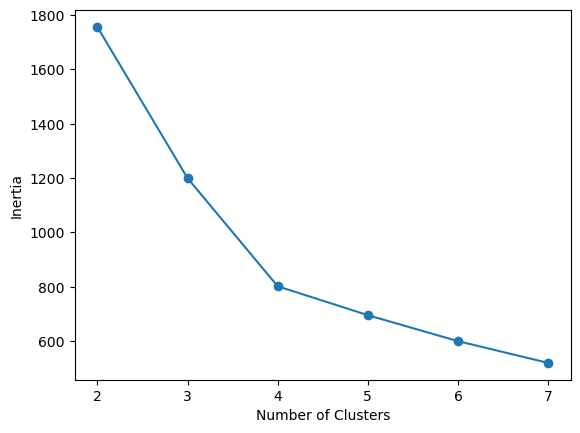

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 8), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [7]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.3f}")

k=2, Silhouette Score=0.345
k=3, Silhouette Score=0.400
k=4, Silhouette Score=0.464
k=5, Silhouette Score=0.464
k=6, Silhouette Score=0.462
k=7, Silhouette Score=0.496


In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [10]:
df.groupby("Cluster")[features].mean()

,Age,Sleep Duration,Stress Level,Heart Rate,Activity_Index,Systolic
Cluster,,,,,,
0,43.000000,7.603814,4.275424,67.788136,455122.881356,127.050847
1,49.750000,6.065625,8.000000,75.000000,900000.000000,140.000000
2,38.084906,6.403774,7.066038,74.000000,229827.358491,128.443396


In [11]:
pd.crosstab(df["Cluster"], df["BMI Category"], normalize='index')

BMI Category,Normal,Obese,Overweight
Cluster,,,
0,0.741525,0.00000,0.258475
1,0.000000,0.00000,1.000000
2,0.386792,0.09434,0.518868


In [13]:
df.to_csv("/Users/vishishtareddy/Desktop/ml/data/processed/lifestyle_cleaned.csv", index=False)